## 🔥 Highlights
- Hybrid Affine + Deep Learning Registration
- Tumor Mask Guided Attention
- NSGA-based Automatic Loss Optimization
- Multimodal MRI Joint Registration

Imports and Initialization 

In [ ]:
import os
import numpy as np
import nibabel as nib
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# -------------------------------
# Reproducibility
# -------------------------------
torch.manual_seed(42)
np.random.seed(42)

# -------------------------------
# Speed optimization
# -------------------------------
torch.backends.cudnn.benchmark = True

# -------------------------------
# Paths
# -------------------------------
DATA_ROOT = "../BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

MISALIGNED_ROOT = "../BraTS2020_MisalignedData_new"

# -------------------------------
# Device
# -------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

# -------------------------------
# Utility functions
# -------------------------------

def load_nifti(path):
    return nib.load(path).get_fdata().astype(np.float32)


def normalize(img):
    """
    Normalize MRI intensities to [0,1]
    using only non-zero voxels
    """
    mask = img > 0
    if np.sum(mask) == 0:
        return img

    img_min = img[mask].min()
    img_max = img[mask].max()

    img = (img - img_min) / (img_max - img_min + 1e-8)
    img[~mask] = 0

    return img

Using device: cuda


Affine Registration

In [ ]:
def register_3d_affine(fixed, moving):

    fixed  = sitk.Cast(fixed, sitk.sitkFloat32)
    moving = sitk.Cast(moving, sitk.sitkFloat32)

    reg = sitk.ImageRegistrationMethod()

    # -----------------------------
    # Metric (good for multimodal)
    # -----------------------------
    reg.SetMetricAsMattesMutualInformation(numberOfHistogramBins=64)

    reg.SetMetricSamplingStrategy(reg.RANDOM)
    reg.SetMetricSamplingPercentage(0.2)

    # -----------------------------
    # Interpolator
    # -----------------------------
    reg.SetInterpolator(sitk.sitkLinear)

    # -----------------------------
    # Optimizer (more stable)
    # -----------------------------
    reg.SetOptimizerAsRegularStepGradientDescent(
        learningRate=2.0,
        minStep=1e-4,
        numberOfIterations=300,
        gradientMagnitudeTolerance=1e-8
    )

    reg.SetOptimizerScalesFromPhysicalShift()

    # -----------------------------
    # Multi-resolution pyramid
    # -----------------------------
    reg.SetShrinkFactorsPerLevel([4,2,1])
    reg.SetSmoothingSigmasPerLevel([2,1,0])
    reg.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    # -----------------------------
    # Initialization (better)
    # -----------------------------
    affine_init = sitk.CenteredTransformInitializer(
        fixed,
        moving,
        sitk.AffineTransform(3),
        sitk.CenteredTransformInitializerFilter.MOMENTS
    )

    reg.SetInitialTransform(affine_init, inPlace=False)

    # -----------------------------
    # Run registration
    # -----------------------------
    final_transform = reg.Execute(fixed, moving)

    return final_transform

Transform to Flow

In [ ]:
def transform_to_flow(transform, reference_image):

    displacement_filter = sitk.TransformToDisplacementFieldFilter()

    # ensure correct datatype
    displacement_filter.SetOutputPixelType(sitk.sitkVectorFloat32)

    # reference grid
    displacement_filter.SetReferenceImage(reference_image)

    disp_field = displacement_filter.Execute(transform)

    # SITK format: [D, H, W, 3]
    flow = sitk.GetArrayFromImage(disp_field).astype(np.float32)

    # Convert to PyTorch format: [3, D, H, W]
    flow = np.moveaxis(flow, -1, 0)

    # ensure contiguous memory
    flow = np.ascontiguousarray(flow)

    return flow

Data Set loading and preprocessing

In [ ]:
import os
import numpy as np
import nibabel as nib
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import SimpleITK as sitk


class BraTSDataset(Dataset):

    def __init__(self, data_root, misaligned_root):

        self.data_root = data_root
        self.misaligned_root = misaligned_root
        self.samples = []

        for patient in os.listdir(data_root):

            p_dir = os.path.join(data_root, patient)

            if not os.path.isdir(p_dir):
                continue

            files = os.listdir(p_dir)
            print(f"Loading patient {patient} with files: {files}")

            t1ce = [f for f in files if "t1ce" in f][0]
            seg  = [f for f in files if "seg" in f][0]

            self.samples.append({
                "patient": patient,
                "fixed": os.path.join(p_dir, t1ce),
                "mask": os.path.join(p_dir, seg)
            })

        print("Patients loaded:", len(self.samples))


    def __len__(self):
        return len(self.samples)


    def normalize(self, img):

        img = img.astype(np.float32)

        if img.max() == img.min():
            return img

        return (img - img.min()) / (img.max() - img.min())


    def resize_volume(self, img, size=(128,128,128)):

        img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)

        img = F.interpolate(
            img,
            size=size,
            mode="trilinear",
            align_corners=False
        )

        return img.squeeze().numpy()


    def resize_mask(self, img, size=(128,128,128)):

        img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)

        img = F.interpolate(
            img,
            size=size,
            mode="nearest"
        )

        return img.squeeze().numpy()


    def load_nifti(self, path):
        return nib.load(path).get_fdata().astype(np.float32)


    def __getitem__(self, idx):

        sample = self.samples[idx]
        patient = sample["patient"]

        fixed = self.load_nifti(sample["fixed"])
        mask  = self.load_nifti(sample["mask"])

        # binary tumor mask
        mask = (mask > 0).astype(np.float32)

        mis_dir = os.path.join(self.misaligned_root, patient)
        files = os.listdir(mis_dir)

        t1    = self.load_nifti(os.path.join(mis_dir, [f for f in files if "t1." in f][0]))
        t2    = self.load_nifti(os.path.join(mis_dir, [f for f in files if "t2." in f][0]))
        flair = self.load_nifti(os.path.join(mis_dir, [f for f in files if "flair" in f][0]))

        # resize volumes
        fixed  = self.resize_volume(fixed)
        t1     = self.resize_volume(t1)
        t2     = self.resize_volume(t2)
        flair  = self.resize_volume(flair)
        mask   = self.resize_mask(mask)

        # normalize
        fixed  = self.normalize(fixed)
        t1     = self.normalize(t1)
        t2     = self.normalize(t2)
        flair  = self.normalize(flair)

        fixed_itk = sitk.GetImageFromArray(fixed)

        # compute rigid transforms
        t1_itk = sitk.GetImageFromArray(t1)
        t2_itk = sitk.GetImageFromArray(t2)
        fl_itk = sitk.GetImageFromArray(flair)

        transform_t1 = register_3d_affine(fixed_itk, t1_itk)
        transform_t2 = register_3d_affine(fixed_itk, t2_itk)
        transform_fl = register_3d_affine(fixed_itk, fl_itk)

        flow_t1 = transform_to_flow(transform_t1, fixed_itk)
        flow_t2 = transform_to_flow(transform_t2, fixed_itk)
        flow_fl = transform_to_flow(transform_fl, fixed_itk)

        return {
            "fixed": torch.from_numpy(fixed).unsqueeze(0).float(),

            "moving_t1": torch.from_numpy(t1).unsqueeze(0).float(),
            "moving_t2": torch.from_numpy(t2).unsqueeze(0).float(),
            "moving_flair": torch.from_numpy(flair).unsqueeze(0).float(),

            "flow_t1": torch.from_numpy(flow_t1).float(),
            "flow_t2": torch.from_numpy(flow_t2).float(),
            "flow_flair": torch.from_numpy(flow_fl).float(),

            "mask": torch.from_numpy(mask).unsqueeze(0).float()
        }

In [ ]:
dataset = BraTSDataset(DATA_ROOT, MISALIGNED_ROOT)

loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

print("Dataset size:", len(dataset))

# sanity check
sample = next(iter(loader))

print("Fixed shape:", sample["fixed"].shape)

print("T1 shape:", sample["moving_t1"].shape)
print("T2 shape:", sample["moving_t2"].shape)
print("FLAIR shape:", sample["moving_flair"].shape)

print("Flow T1 shape:", sample["flow_t1"].shape)
print("Flow T2 shape:", sample["flow_t2"].shape)
print("Flow FLAIR shape:", sample["flow_flair"].shape)

print("Mask shape:", sample["mask"].shape)

Loading patient BraTS20_Training_001 with files: ['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']
Loading patient BraTS20_Training_002 with files: ['BraTS20_Training_002_flair.nii', 'BraTS20_Training_002_seg.nii', 'BraTS20_Training_002_t1.nii', 'BraTS20_Training_002_t1ce.nii', 'BraTS20_Training_002_t2.nii']
Loading patient BraTS20_Training_003 with files: ['BraTS20_Training_003_flair.nii', 'BraTS20_Training_003_seg.nii', 'BraTS20_Training_003_t1.nii', 'BraTS20_Training_003_t1ce.nii', 'BraTS20_Training_003_t2.nii']
Loading patient BraTS20_Training_004 with files: ['BraTS20_Training_004_flair.nii', 'BraTS20_Training_004_seg.nii', 'BraTS20_Training_004_t1.nii', 'BraTS20_Training_004_t1ce.nii', 'BraTS20_Training_004_t2.nii']
Loading patient BraTS20_Training_005 with files: ['BraTS20_Training_005_flair.nii', 'BraTS20_Training_005_seg.nii', 'BraTS20_Training_005_t1.nii', 'BraTS20_

VoxelMorph with Mask Guided Spatial Network

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------
# Residual Block
# -------------------------
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.conv1 = nn.Conv3d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv3d(out_ch, out_ch, 3, padding=1)

        self.relu = nn.ReLU(inplace=True)

        if in_ch != out_ch:
            self.skip = nn.Conv3d(in_ch, out_ch, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x):
        identity = self.skip(x)

        out = self.relu(self.conv1(x))
        out = self.conv2(out)

        return self.relu(out + identity)


# -------------------------
# Mask-Guided Spatial Attention
# -------------------------
class SpatialAttention(nn.Module):
    def __init__(self, in_ch):
        super().__init__()

        self.conv = nn.Conv3d(in_ch + 1, 1, kernel_size=3, padding=1)

    def forward(self, x, mask):

        # resize mask to feature size
        mask_resized = F.interpolate(mask, size=x.shape[2:], mode='trilinear', align_corners=False)

        attn = torch.cat([x, mask_resized], dim=1)

        attn = torch.sigmoid(self.conv(attn))

        return x * attn


# -------------------------
# Enhanced Residual VoxelMorph
# -------------------------
class ResidualVoxelMorph_Attn(nn.Module):

    def __init__(self):
        super().__init__()

        # -------------------------
        # Encoder
        # -------------------------
        self.enc1 = ResBlock(14, 32)
        self.enc2 = ResBlock(32, 64)
        self.enc3 = ResBlock(64, 128)

        self.pool = nn.MaxPool3d(2)

        # -------------------------
        # Bottleneck
        # -------------------------
        self.bottleneck = ResBlock(128, 128)

        # -------------------------
        # Attention Gates
        # -------------------------
        self.attn2 = SpatialAttention(64)
        self.attn1 = SpatialAttention(32)

        # -------------------------
        # Decoder
        # -------------------------
        self.up2 = nn.ConvTranspose3d(128, 64, 2, stride=2)
        self.dec2 = ResBlock(128, 64)

        self.up1 = nn.ConvTranspose3d(64, 32, 2, stride=2)
        self.dec1 = ResBlock(64, 32)

        # -------------------------
        # Flow Head
        # -------------------------
        self.flow = nn.Conv3d(32, 9, 3, padding=1)

        # Learnable scaling factor (IMPORTANT)
        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):

        # Extract mask (last channel)
        mask = x[:, -1:, :, :, :]

        # -------------------------
        # Encoder
        # -------------------------
        e1 = self.enc1(x)
        p1 = self.pool(e1)

        e2 = self.enc2(p1)
        p2 = self.pool(e2)

        e3 = self.enc3(p2)

        # -------------------------
        # Bottleneck
        # -------------------------
        b = self.bottleneck(e3)

        # -------------------------
        # Decoder + Attention
        # -------------------------
        d2 = self.up2(b)

        # apply attention to skip
        e2_attn = self.attn2(e2, mask)

        d2 = torch.cat([d2, e2_attn], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)

        e1_attn = self.attn1(e1, mask)

        d1 = torch.cat([d1, e1_attn], dim=1)
        d1 = self.dec1(d1)

        # -------------------------
        # Flow Prediction
        # -------------------------
        flow = self.flow(d1)

        flow = torch.tanh(flow)

        # scaled residual (VERY IMPORTANT)
        flow = self.alpha * flow

        return flow

Wraping the misaligned Volume with the calculated flow

In [ ]:
import torch
import torch.nn.functional as F


def warp(img, flow, mode="bilinear"):

    B, C, D, H, W = img.shape
    device = img.device

    # create normalized grid
    z = torch.linspace(-1, 1, D, device=device)
    y = torch.linspace(-1, 1, H, device=device)
    x = torch.linspace(-1, 1, W, device=device)

    zz, yy, xx = torch.meshgrid(z, y, x, indexing="ij")

    grid = torch.stack((xx, yy, zz), dim=-1)   # [D,H,W,3]

    grid = grid.unsqueeze(0).repeat(B,1,1,1,1)

    # convert flow format
    flow = flow.permute(0,2,3,4,1)

    # normalize displacement
    flow[...,0] /= (W - 1) / 2
    flow[...,1] /= (H - 1) / 2
    flow[...,2] /= (D - 1) / 2

    new_grid = grid + flow

    warped = F.grid_sample(
        img,
        new_grid,
        mode=mode,
        padding_mode="border",
        align_corners=True
    )

    return warped

Loss Function

In [ ]:
def ncc_loss(I, J):

    B = I.shape[0]

    I = I.view(B, -1)
    J = J.view(B, -1)

    I = I - I.mean(dim=1, keepdim=True)
    J = J - J.mean(dim=1, keepdim=True)

    numerator = (I * J).sum(dim=1)
    denominator = torch.sqrt((I**2).sum(dim=1) * (J**2).sum(dim=1))

    ncc = numerator / (denominator + 1e-5)

    return -ncc.mean()


def dice_loss(pred, target):

    smooth = 1.0

    B = pred.shape[0]

    pred = pred.view(B, -1)
    target = target.view(B, -1)

    intersection = (pred * target).sum(dim=1)

    dice = (2 * intersection + smooth) / (pred.sum(dim=1) + target.sum(dim=1) + smooth)

    return 1 - dice.mean()


def smoothness_loss(flow):

    # flow shape [B,3,D,H,W]

    dz = torch.abs(flow[:,:,1:,:,:] - flow[:,:,:-1,:,:]).mean()
    dy = torch.abs(flow[:,:,:,1:,:] - flow[:,:,:,:-1,:]).mean()
    dx = torch.abs(flow[:,:,:,:,1:] - flow[:,:,:,:,:-1]).mean()

    return dx + dy + dz


Model Initialization

In [ ]:
# -------------------------
# Initialize model
# -------------------------
model = ResidualVoxelMorph_Attn().to(DEVICE)

# Initialize final flow layer close to zero
for m in model.modules():
    if isinstance(m, nn.Conv3d) and m.out_channels == 9:   # CHANGED (was 3)
        nn.init.normal_(m.weight, mean=0, std=1e-5)
        nn.init.constant_(m.bias, 0)

# -------------------------
# Optimizer
# -------------------------
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# -------------------------
# Sanity check sample
# -------------------------
with torch.no_grad():
    sample = next(iter(loader))

print("Fixed image shape:   ", sample["fixed"].shape)

print("T1 shape:            ", sample["moving_t1"].shape)
print("T2 shape:            ", sample["moving_t2"].shape)
print("FLAIR shape:         ", sample["moving_flair"].shape)

print("Flow T1 shape:       ", sample["flow_t1"].shape)
print("Flow T2 shape:       ", sample["flow_t2"].shape)
print("Flow FLAIR shape:    ", sample["flow_flair"].shape)

print("Mask shape:          ", sample["mask"].shape)



Fixed image shape:    torch.Size([1, 1, 128, 128, 128])
T1 shape:             torch.Size([1, 1, 128, 128, 128])
T2 shape:             torch.Size([1, 1, 128, 128, 128])
FLAIR shape:          torch.Size([1, 1, 128, 128, 128])
Flow T1 shape:        torch.Size([1, 3, 128, 128, 128])
Flow T2 shape:        torch.Size([1, 3, 128, 128, 128])
Flow FLAIR shape:     torch.Size([1, 3, 128, 128, 128])
Mask shape:           torch.Size([1, 1, 128, 128, 128])


NSGA Optimization

In [ ]:
import torch
import numpy as np
import random
import json
import copy
from tqdm import tqdm

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# NSGA PARAMETERS (FIXED)
# -------------------------
POP_SIZE = 20
GENERATIONS = 10
MUTATION_RATE = 0.2

TRAIN_STEPS = 3   # short training per candidate
EVAL_STEPS = 3    # evaluation batches

# --------------------------------
# Weight normalization
# --------------------------------
def normalize_weights(w):
    w = np.maximum(w, 1e-6)
    return w / np.sum(w)


# --------------------------------
# FITNESS EVALUATION (CORRECTED)
# --------------------------------
def evaluate_fitness(weights, base_model, loader):

    w1, w2, w3 = weights

    # 🔥 CLONE MODEL (CRITICAL FIX)
    model = copy.deepcopy(base_model).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # -------------------------
    # SHORT TRAINING PHASE
    # -------------------------
    model.train()

    for i, batch in enumerate(loader):

        if i >= TRAIN_STEPS:
            break

        fixed = batch["fixed"].to(DEVICE)
        t1 = batch["moving_t1"].to(DEVICE)
        t2 = batch["moving_t2"].to(DEVICE)
        flair = batch["moving_flair"].to(DEVICE)

        flow_t1 = batch["flow_t1"].to(DEVICE)
        flow_t2 = batch["flow_t2"].to(DEVICE)
        flow_flair = batch["flow_flair"].to(DEVICE)

        mask = batch["mask"].to(DEVICE)

        rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)
        x = torch.cat([fixed, t1, t2, flair, rigid_flow, mask], dim=1)

        residual_flow = model(x)

        res_t1 = residual_flow[:,0:3]
        res_t2 = residual_flow[:,3:6]
        res_flair = residual_flow[:,6:9]

        final_flow_t1 = flow_t1 + res_t1
        final_flow_t2 = flow_t2 + res_t2
        final_flow_flair = flow_flair + res_flair

        reg_t1 = warp(t1, final_flow_t1)
        reg_t2 = warp(t2, final_flow_t2)
        reg_flair = warp(flair, final_flow_flair)

        mask_t1 = warp(mask, final_flow_t1, mode="nearest")
        mask_t2 = warp(mask, final_flow_t2, mode="nearest")
        mask_flair = warp(mask, final_flow_flair, mode="nearest")

        # LOSS (same as training)
        loss_sim = (
            ncc_loss(fixed, reg_t1) +
            ncc_loss(fixed, reg_t2) +
            ncc_loss(fixed, reg_flair)
        ) / 3

        loss_dice = (
            dice_loss(mask_t1, mask) +
            dice_loss(mask_t2, mask) +
            dice_loss(mask_flair, mask)
        ) / 3

        loss_smooth = (
            smoothness_loss(final_flow_t1) +
            smoothness_loss(final_flow_t2) +
            smoothness_loss(final_flow_flair)
        ) / 3

        loss = w1*loss_sim + w2*loss_dice + w3*loss_smooth

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # -------------------------
    # EVALUATION PHASE
    # -------------------------
    model.eval()

    dice_total, ssim_total, psnr_total = 0, 0, 0
    count = 0

    with torch.no_grad():

        for i, batch in enumerate(loader):

            if i >= EVAL_STEPS:
                break

            fixed = batch["fixed"].to(DEVICE)

            t1 = batch["moving_t1"].to(DEVICE)
            t2 = batch["moving_t2"].to(DEVICE)
            flair = batch["moving_flair"].to(DEVICE)

            flow_t1 = batch["flow_t1"].to(DEVICE)
            flow_t2 = batch["flow_t2"].to(DEVICE)
            flow_flair = batch["flow_flair"].to(DEVICE)

            mask = batch["mask"].to(DEVICE)

            rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)
            x = torch.cat([fixed, t1, t2, flair, rigid_flow, mask], dim=1)

            residual_flow = model(x)

            res_t1 = residual_flow[:,0:3]
            res_t2 = residual_flow[:,3:6]
            res_flair = residual_flow[:,6:9]

            final_flow_t1 = flow_t1 + res_t1
            final_flow_t2 = flow_t2 + res_t2
            final_flow_flair = flow_flair + res_flair

            reg_t1 = warp(t1, final_flow_t1)
            reg_t2 = warp(t2, final_flow_t2)
            reg_flair = warp(flair, final_flow_flair)

            mask_t1 = warp(mask, final_flow_t1, mode="nearest")
            mask_t2 = warp(mask, final_flow_t2, mode="nearest")
            mask_flair = warp(mask, final_flow_flair, mode="nearest")

            # Dice
            dice_score = (
                1 - dice_loss(mask_t1, mask) +
                1 - dice_loss(mask_t2, mask) +
                1 - dice_loss(mask_flair, mask)
            ) / 3

            dice_total += dice_score.item()

            # SSIM + PSNR
            fixed_np = fixed[0,0].cpu().numpy()

            for reg in [reg_t1, reg_t2, reg_flair]:

                reg_np = reg[0,0].cpu().numpy()

                ssim_total += ssim(fixed_np, reg_np,
                                   data_range=reg_np.max() - reg_np.min())

                psnr_total += psnr(fixed_np, reg_np,
                                   data_range=reg_np.max() - reg_np.min())

                count += 1

    dice_avg = dice_total / EVAL_STEPS
    ssim_avg = ssim_total / count
    psnr_avg = psnr_total / count

    # 🔥 NORMALIZATION (IMPORTANT)
    psnr_avg = psnr_avg / 50.0

    return np.array([-dice_avg, -ssim_avg, -psnr_avg])


# --------------------------------
# Population init
# --------------------------------
def initialize_population():
    return [normalize_weights(np.random.rand(3)) for _ in range(POP_SIZE)]


# --------------------------------
# Mutation + Crossover
# --------------------------------
def mutate(w):
    if random.random() < MUTATION_RATE:
        w += np.random.normal(0, 0.1, 3)
    return normalize_weights(w)


def crossover(p1, p2):
    alpha = random.random()
    return normalize_weights(alpha*p1 + (1-alpha)*p2)


# --------------------------------
# Simple Pareto (lightweight)
# --------------------------------
def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)


def pareto_front(pop, obj):
    front = []
    for i in range(len(pop)):
        if not any(dominates(obj[j], obj[i]) for j in range(len(pop))):
            front.append(i)
    return front


# --------------------------------
# MAIN NSGA LOOP
# --------------------------------
def run_nsga(base_model, loader):

    population = initialize_population()

    for gen in range(GENERATIONS):

        print(f"\nGeneration {gen+1}/{GENERATIONS}")

        objectives = []

        for w in tqdm(population):
            obj = evaluate_fitness(w, base_model, loader)
            objectives.append(obj)

        objectives = np.array(objectives)

        front = pareto_front(population, objectives)

        best_idx = front[0]
        best_weights = population[best_idx]

        print("Best weights:", best_weights)

        # next generation
        new_pop = []
        while len(new_pop) < POP_SIZE:
            p1, p2 = random.sample(population, 2)
            child = mutate(crossover(p1, p2))
            new_pop.append(child)

        population = new_pop

    return best_weights


# --------------------------------
# RUN
# --------------------------------
print("🚀 Starting NSGA optimization")

best_weights = run_nsga(model, loader)

print("✅ Best weights found:", best_weights)

# Save
with open("optimal_loss_weights.json", "w") as f:
    json.dump({
        "w_ncc": float(best_weights[0]),
        "w_dice": float(best_weights[1]),
        "w_smooth": float(best_weights[2])
    }, f, indent=4)

print("💾 Weights saved")

🚀 Starting NSGA optimization

Generation 1/10


100%|██████████| 20/20 [54:23<00:00, 163.16s/it] 


Best weights: [0.53575545 0.43819217 0.02605238]

Generation 2/10


100%|██████████| 20/20 [41:12<00:00, 123.63s/it]


Best weights: [0.21252154 0.28197135 0.50550711]

Generation 3/10


...

Best weights: [0.26974664 0.33868173 0.39157163]

Generation 9/10


100%|██████████| 20/20 [38:55<00:00, 116.78s/it]


Best weights: [0.29970084 0.29233184 0.40796732]

Generation 10/10


100%|██████████| 20/20 [39:30<00:00, 118.53s/it]

Best weights: [0.2232591  0.33835116 0.43838975]
✅ Best weights found: [0.2232591  0.33835116 0.43838975]
💾 Weights saved


Model Training

In [ ]:
from tqdm import tqdm
import torch
import os
import json

EPOCHS = 100


with open("optimal_loss_weights.json") as f:

    weights = json.load(f)

w1 = weights["w_ncc"]
w2 = weights["w_dice"]
w3 = weights["w_smooth"]

print("Loaded optimized weights:")
print("NCC:", w1)
print("Dice:", w2)
print("Smooth:", w3)

loader_len = len(loader)

CHECKPOINT_PATH = "checkpoint_latest.pth"
BEST_MODEL_PATH = "best_model.pth"

start_epoch = 0
best_loss = float("inf")

# -------------------------
# Resume if checkpoint exists
# -------------------------
if os.path.exists(CHECKPOINT_PATH):

    print("Resuming training from checkpoint...")

    checkpoint = torch.load(CHECKPOINT_PATH)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_loss = checkpoint["best_loss"]

    print(f"Resumed from epoch {start_epoch}")


# -------------------------
# Training Loop
# -------------------------
for epoch in range(start_epoch, EPOCHS):

    model.train()

    epoch_loss = 0

    with tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as pbar:

        for batch in pbar:

            fixed = batch["fixed"].float().to(DEVICE)

            t1 = batch["moving_t1"].float().to(DEVICE)
            t2 = batch["moving_t2"].float().to(DEVICE)
            flair = batch["moving_flair"].float().to(DEVICE)

            flow_t1 = batch["flow_t1"].float().to(DEVICE)
            flow_t2 = batch["flow_t2"].float().to(DEVICE)
            flow_flair = batch["flow_flair"].float().to(DEVICE)

            mask = batch["mask"].float().to(DEVICE)

            # combine rigid flows
            rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)

            x = torch.cat([fixed, t1, t2, flair, rigid_flow, mask], dim=1)

            residual_flow = model(x)

            # split residual flows
            res_t1 = residual_flow[:,0:3]
            res_t2 = residual_flow[:,3:6]
            res_flair = residual_flow[:,6:9]

            final_flow_t1 = flow_t1 + res_t1
            final_flow_t2 = flow_t2 + res_t2
            final_flow_flair = flow_flair + res_flair

            # warp
            reg_t1 = warp(t1, final_flow_t1)
            reg_t2 = warp(t2, final_flow_t2)
            reg_flair = warp(flair, final_flow_flair)

            mask_t1 = warp(mask, final_flow_t1, mode="nearest")
            mask_t2 = warp(mask, final_flow_t2, mode="nearest")
            mask_flair = warp(mask, final_flow_flair, mode="nearest")

            # losses
            loss_sim = (
                ncc_loss(fixed, reg_t1) +
                ncc_loss(fixed, reg_t2) +
                ncc_loss(fixed, reg_flair)
            ) / 3

            loss_dice = (
                dice_loss(mask_t1, mask) +
                dice_loss(mask_t2, mask) +
                dice_loss(mask_flair, mask)
            ) / 3

            loss_smooth = (
                smoothness_loss(final_flow_t1) +
                smoothness_loss(final_flow_t2) +
                smoothness_loss(final_flow_flair)
            ) / 3

            loss = w1 * loss_sim + w2 * loss_dice + w3 * loss_smooth

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            epoch_loss += loss.item()

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / loader_len

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.6f}")

    # -------------------------
    # Save checkpoint
    # -------------------------
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss
    }, CHECKPOINT_PATH)

    print("Checkpoint saved")

    # -------------------------
    # Save best model
    # -------------------------
    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print("Best model updated")

C:\Users\balam\AppData\Local\Temp\ipykernel_30588\727632652.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH)


Loaded optimized weights:
NCC: 0.22325909771371844
Dice: 0.33835115611660477
Smooth: 0.43838974616967685
Resuming training from checkpoint...
Resumed from epoch 8


Epoch 9/100: 100%|██████████| 368/368 [1:29:16<00:00, 14.55s/batch, loss=-0.2149]



Epoch 9 Average Loss: -0.204340
Checkpoint saved
Best model updated


Epoch 10/100: 100%|██████████| 368/368 [1:29:14<00:00, 14.55s/batch, loss=-0.1907]


...


Epoch 37 Average Loss: -0.204330
Checkpoint saved


Epoch 38/100: 100%|██████████| 368/368 [1:41:12<00:00, 16.50s/batch, loss=-0.2121]



Epoch 38 Average Loss: -0.204372
Checkpoint saved
Best model updated


Epoch 39/100:   6%|▋         | 23/368 [09:00<2:15:14, 23.52s/batch, loss=-0.2041]


KeyboardInterrupt: 

In [ ]:
from tqdm import tqdm
import torch
import os
import json

EPOCHS = 100


with open("optimal_loss_weights.json") as f:

    weights = json.load(f)

w1 = weights["w_ncc"]
w2 = weights["w_dice"]
w3 = weights["w_smooth"]

print("Loaded optimized weights:")
print("NCC:", w1)
print("Dice:", w2)
print("Smooth:", w3)

loader_len = len(loader)

CHECKPOINT_PATH = "checkpoint_latest.pth"
BEST_MODEL_PATH = "best_model.pth"

start_epoch = 0
best_loss = float("inf")

# -------------------------
# Resume if checkpoint exists
# -------------------------
if os.path.exists(CHECKPOINT_PATH):

    print("Resuming training from checkpoint...")

    checkpoint = torch.load(CHECKPOINT_PATH)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_loss = checkpoint["best_loss"]

    print(f"Resumed from epoch {start_epoch}")


# -------------------------
# Training Loop
# -------------------------
for epoch in range(start_epoch, EPOCHS):

    model.train()

    epoch_loss = 0

    with tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as pbar:

        for batch in pbar:

            fixed = batch["fixed"].float().to(DEVICE)

            t1 = batch["moving_t1"].float().to(DEVICE)
            t2 = batch["moving_t2"].float().to(DEVICE)
            flair = batch["moving_flair"].float().to(DEVICE)

            flow_t1 = batch["flow_t1"].float().to(DEVICE)
            flow_t2 = batch["flow_t2"].float().to(DEVICE)
            flow_flair = batch["flow_flair"].float().to(DEVICE)

            mask = batch["mask"].float().to(DEVICE)

            # combine rigid flows
            rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)

            x = torch.cat([fixed, t1, t2, flair, rigid_flow, mask], dim=1)

            residual_flow = model(x)

            # split residual flows
            res_t1 = residual_flow[:,0:3]
            res_t2 = residual_flow[:,3:6]
            res_flair = residual_flow[:,6:9]

            final_flow_t1 = flow_t1 + res_t1
            final_flow_t2 = flow_t2 + res_t2
            final_flow_flair = flow_flair + res_flair

            # warp
            reg_t1 = warp(t1, final_flow_t1)
            reg_t2 = warp(t2, final_flow_t2)
            reg_flair = warp(flair, final_flow_flair)

            mask_t1 = warp(mask, final_flow_t1, mode="nearest")
            mask_t2 = warp(mask, final_flow_t2, mode="nearest")
            mask_flair = warp(mask, final_flow_flair, mode="nearest")

            # losses
            loss_sim = (
                ncc_loss(fixed, reg_t1) +
                ncc_loss(fixed, reg_t2) +
                ncc_loss(fixed, reg_flair)
            ) / 3

            loss_dice = (
                dice_loss(mask_t1, mask) +
                dice_loss(mask_t2, mask) +
                dice_loss(mask_flair, mask)
            ) / 3

            loss_smooth = (
                smoothness_loss(final_flow_t1) +
                smoothness_loss(final_flow_t2) +
                smoothness_loss(final_flow_flair)
            ) / 3

            loss = w1 * loss_sim + w2 * loss_dice + w3 * loss_smooth

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            epoch_loss += loss.item()

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / loader_len

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.6f}")

    # -------------------------
    # Save checkpoint
    # -------------------------
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss
    }, CHECKPOINT_PATH)

    print("Checkpoint saved")

    # -------------------------
    # Save best model
    # -------------------------
    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print("Best model updated")

Loaded optimized weights:
NCC: 0.22325909771371844
Dice: 0.33835115611660477
Smooth: 0.43838974616967685
Resuming training from checkpoint...


C:\Users\balam\AppData\Local\Temp\ipykernel_30588\727632652.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH)


Resumed from epoch 38


Epoch 39/100: 100%|██████████| 368/368 [1:37:12<00:00, 15.85s/batch, loss=-0.2040]



Epoch 39 Average Loss: -0.204415
Checkpoint saved
Best model updated


...


Epoch 50 Average Loss: -0.204650
Checkpoint saved
Best model updated


Epoch 51/100: 100%|██████████| 368/368 [1:38:03<00:00, 15.99s/batch, loss=-0.2053]



Epoch 51 Average Loss: -0.204725
Checkpoint saved
Best model updated


Epoch 52/100:  13%|█▎        | 48/368 [12:31<1:23:29, 15.66s/batch, loss=-0.2051]


KeyboardInterrupt: 

In [ ]:
from tqdm import tqdm
import torch
import os
import json

EPOCHS = 100


with open("optimal_loss_weights.json") as f:

    weights = json.load(f)

w1 = weights["w_ncc"]
w2 = weights["w_dice"]
w3 = weights["w_smooth"]

print("Loaded optimized weights:")
print("NCC:", w1)
print("Dice:", w2)
print("Smooth:", w3)

loader_len = len(loader)

CHECKPOINT_PATH = "checkpoint_latest.pth"
BEST_MODEL_PATH = "best_model.pth"

start_epoch = 0
best_loss = float("inf")

# -------------------------
# Resume if checkpoint exists
# -------------------------
if os.path.exists(CHECKPOINT_PATH):

    print("Resuming training from checkpoint...")

    checkpoint = torch.load(CHECKPOINT_PATH)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_loss = checkpoint["best_loss"]

    print(f"Resumed from epoch {start_epoch}")


# -------------------------
# Training Loop
# -------------------------
for epoch in range(start_epoch, EPOCHS):

    model.train()

    epoch_loss = 0

    with tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as pbar:

        for batch in pbar:

            fixed = batch["fixed"].float().to(DEVICE)

            t1 = batch["moving_t1"].float().to(DEVICE)
            t2 = batch["moving_t2"].float().to(DEVICE)
            flair = batch["moving_flair"].float().to(DEVICE)

            flow_t1 = batch["flow_t1"].float().to(DEVICE)
            flow_t2 = batch["flow_t2"].float().to(DEVICE)
            flow_flair = batch["flow_flair"].float().to(DEVICE)

            mask = batch["mask"].float().to(DEVICE)

            # combine rigid flows
            rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)

            x = torch.cat([fixed, t1, t2, flair, rigid_flow, mask], dim=1)

            residual_flow = model(x)

            # split residual flows
            res_t1 = residual_flow[:,0:3]
            res_t2 = residual_flow[:,3:6]
            res_flair = residual_flow[:,6:9]

            final_flow_t1 = flow_t1 + res_t1
            final_flow_t2 = flow_t2 + res_t2
            final_flow_flair = flow_flair + res_flair

            # warp
            reg_t1 = warp(t1, final_flow_t1)
            reg_t2 = warp(t2, final_flow_t2)
            reg_flair = warp(flair, final_flow_flair)

            mask_t1 = warp(mask, final_flow_t1, mode="nearest")
            mask_t2 = warp(mask, final_flow_t2, mode="nearest")
            mask_flair = warp(mask, final_flow_flair, mode="nearest")

            # losses
            loss_sim = (
                ncc_loss(fixed, reg_t1) +
                ncc_loss(fixed, reg_t2) +
                ncc_loss(fixed, reg_flair)
            ) / 3

            loss_dice = (
                dice_loss(mask_t1, mask) +
                dice_loss(mask_t2, mask) +
                dice_loss(mask_flair, mask)
            ) / 3

            loss_smooth = (
                smoothness_loss(final_flow_t1) +
                smoothness_loss(final_flow_t2) +
                smoothness_loss(final_flow_flair)
            ) / 3

            loss = w1 * loss_sim + w2 * loss_dice + w3 * loss_smooth

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            epoch_loss += loss.item()

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / loader_len

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.6f}")

    # -------------------------
    # Save checkpoint
    # -------------------------
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss
    }, CHECKPOINT_PATH)

    print("Checkpoint saved")

    # -------------------------
    # Save best model
    # -------------------------
    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print("Best model updated")

C:\Users\balam\AppData\Local\Temp\ipykernel_25088\727632652.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH)


Loaded optimized weights:
NCC: 0.22325909771371844
Dice: 0.33835115611660477
Smooth: 0.43838974616967685
Resuming training from checkpoint...
Resumed from epoch 51


Epoch 52/100: 100%|██████████| 368/368 [2:10:30<00:00, 21.28s/batch, loss=-0.1976]  



Epoch 52 Average Loss: -0.204882
Checkpoint saved
Best model updated


Epoch 53/100: 100%|██████████| 368/368 [1:41:45<00:00, 16.59s/batch, loss=-0.1980]


...

Epoch 66/100: 100%|██████████| 368/368 [1:45:17<00:00, 17.17s/batch, loss=-0.2156]



Epoch 66 Average Loss: -0.208064
Checkpoint saved
Best model updated


Epoch 67/100: 100%|██████████| 368/368 [1:45:11<00:00, 17.15s/batch, loss=-0.2131]



Epoch 67 Average Loss: -0.208170
Checkpoint saved
Best model updated


Epoch 68/100:  91%|█████████▏| 336/368 [1:36:37<08:43, 16.37s/batch, loss=-0.2033]

In [ ]:
from tqdm import tqdm
import torch
import os
import json

EPOCHS = 100


with open("optimal_loss_weights.json") as f:

    weights = json.load(f)

w1 = weights["w_ncc"]
w2 = weights["w_dice"]
w3 = weights["w_smooth"]

print("Loaded optimized weights:")
print("NCC:", w1)
print("Dice:", w2)
print("Smooth:", w3)

loader_len = len(loader)

CHECKPOINT_PATH = "checkpoint_latest.pth"
BEST_MODEL_PATH = "best_model.pth"

start_epoch = 0
best_loss = float("inf")

# -------------------------
# Resume if checkpoint exists
# -------------------------
if os.path.exists(CHECKPOINT_PATH):

    print("Resuming training from checkpoint...")

    checkpoint = torch.load(CHECKPOINT_PATH)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_loss = checkpoint["best_loss"]

    print(f"Resumed from epoch {start_epoch}")


# -------------------------
# Training Loop
# -------------------------
for epoch in range(start_epoch, EPOCHS):

    model.train()

    epoch_loss = 0

    with tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as pbar:

        for batch in pbar:

            fixed = batch["fixed"].float().to(DEVICE)

            t1 = batch["moving_t1"].float().to(DEVICE)
            t2 = batch["moving_t2"].float().to(DEVICE)
            flair = batch["moving_flair"].float().to(DEVICE)

            flow_t1 = batch["flow_t1"].float().to(DEVICE)
            flow_t2 = batch["flow_t2"].float().to(DEVICE)
            flow_flair = batch["flow_flair"].float().to(DEVICE)

            mask = batch["mask"].float().to(DEVICE)

            # combine rigid flows
            rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)

            x = torch.cat([fixed, t1, t2, flair, rigid_flow, mask], dim=1)

            residual_flow = model(x)

            # split residual flows
            res_t1 = residual_flow[:,0:3]
            res_t2 = residual_flow[:,3:6]
            res_flair = residual_flow[:,6:9]

            final_flow_t1 = flow_t1 + res_t1
            final_flow_t2 = flow_t2 + res_t2
            final_flow_flair = flow_flair + res_flair

            # warp
            reg_t1 = warp(t1, final_flow_t1)
            reg_t2 = warp(t2, final_flow_t2)
            reg_flair = warp(flair, final_flow_flair)

            mask_t1 = warp(mask, final_flow_t1, mode="nearest")
            mask_t2 = warp(mask, final_flow_t2, mode="nearest")
            mask_flair = warp(mask, final_flow_flair, mode="nearest")

            # losses
            loss_sim = (
                ncc_loss(fixed, reg_t1) +
                ncc_loss(fixed, reg_t2) +
                ncc_loss(fixed, reg_flair)
            ) / 3

            loss_dice = (
                dice_loss(mask_t1, mask) +
                dice_loss(mask_t2, mask) +
                dice_loss(mask_flair, mask)
            ) / 3

            loss_smooth = (
                smoothness_loss(final_flow_t1) +
                smoothness_loss(final_flow_t2) +
                smoothness_loss(final_flow_flair)
            ) / 3

            loss = w1 * loss_sim + w2 * loss_dice + w3 * loss_smooth

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            epoch_loss += loss.item()

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / loader_len

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.6f}")

    # -------------------------
    # Save checkpoint
    # -------------------------
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss
    }, CHECKPOINT_PATH)

    print("Checkpoint saved")

    # -------------------------
    # Save best model
    # -------------------------
    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print("Best model updated")

C:\Users\balam\AppData\Local\Temp\ipykernel_18576\727632652.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH)


Loaded optimized weights:
NCC: 0.22325909771371844
Dice: 0.33835115611660477
Smooth: 0.43838974616967685
Resuming training from checkpoint...
Resumed from epoch 67


Epoch 68/100: 100%|██████████| 368/368 [1:36:22<00:00, 15.71s/batch, loss=-0.2110]



Epoch 68 Average Loss: -0.208242
Checkpoint saved
Best model updated


Epoch 69/100: 100%|██████████| 368/368 [1:31:50<00:00, 14.98s/batch, loss=-0.2082]


...


Epoch 81 Average Loss: -0.209435
Checkpoint saved
Best model updated


Epoch 82/100: 100%|██████████| 368/368 [1:34:17<00:00, 15.37s/batch, loss=-0.2102]



Epoch 82 Average Loss: -0.209463
Checkpoint saved
Best model updated


Epoch 83/100:  45%|████▍     | 164/368 [41:20<51:24, 15.12s/batch, loss=-0.2093]  


KeyboardInterrupt: 

In [ ]:
from tqdm import tqdm
import torch
import os
import json

EPOCHS = 100


with open("optimal_loss_weights.json") as f:

    weights = json.load(f)

w1 = weights["w_ncc"]
w2 = weights["w_dice"]
w3 = weights["w_smooth"]

print("Loaded optimized weights:")
print("NCC:", w1)
print("Dice:", w2)
print("Smooth:", w3)

loader_len = len(loader)

CHECKPOINT_PATH = "checkpoint_latest.pth"
BEST_MODEL_PATH = "best_model.pth"

start_epoch = 0
best_loss = float("inf")

# -------------------------
# Resume if checkpoint exists
# -------------------------
if os.path.exists(CHECKPOINT_PATH):

    print("Resuming training from checkpoint...")

    checkpoint = torch.load(CHECKPOINT_PATH)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_loss = checkpoint["best_loss"]

    print(f"Resumed from epoch {start_epoch}")


# -------------------------
# Training Loop
# -------------------------
for epoch in range(start_epoch, EPOCHS):

    model.train()

    epoch_loss = 0

    with tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as pbar:

        for batch in pbar:

            fixed = batch["fixed"].float().to(DEVICE)

            t1 = batch["moving_t1"].float().to(DEVICE)
            t2 = batch["moving_t2"].float().to(DEVICE)
            flair = batch["moving_flair"].float().to(DEVICE)

            flow_t1 = batch["flow_t1"].float().to(DEVICE)
            flow_t2 = batch["flow_t2"].float().to(DEVICE)
            flow_flair = batch["flow_flair"].float().to(DEVICE)

            mask = batch["mask"].float().to(DEVICE)

            # combine rigid flows
            rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)

            x = torch.cat([fixed, t1, t2, flair, rigid_flow, mask], dim=1)

            residual_flow = model(x)

            # split residual flows
            res_t1 = residual_flow[:,0:3]
            res_t2 = residual_flow[:,3:6]
            res_flair = residual_flow[:,6:9]

            final_flow_t1 = flow_t1 + res_t1
            final_flow_t2 = flow_t2 + res_t2
            final_flow_flair = flow_flair + res_flair

            # warp
            reg_t1 = warp(t1, final_flow_t1)
            reg_t2 = warp(t2, final_flow_t2)
            reg_flair = warp(flair, final_flow_flair)

            mask_t1 = warp(mask, final_flow_t1, mode="nearest")
            mask_t2 = warp(mask, final_flow_t2, mode="nearest")
            mask_flair = warp(mask, final_flow_flair, mode="nearest")

            # losses
            loss_sim = (
                ncc_loss(fixed, reg_t1) +
                ncc_loss(fixed, reg_t2) +
                ncc_loss(fixed, reg_flair)
            ) / 3

            loss_dice = (
                dice_loss(mask_t1, mask) +
                dice_loss(mask_t2, mask) +
                dice_loss(mask_flair, mask)
            ) / 3

            loss_smooth = (
                smoothness_loss(final_flow_t1) +
                smoothness_loss(final_flow_t2) +
                smoothness_loss(final_flow_flair)
            ) / 3

            loss = w1 * loss_sim + w2 * loss_dice + w3 * loss_smooth

            optimizer.zero_grad()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            epoch_loss += loss.item()

            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = epoch_loss / loader_len

    print(f"\nEpoch {epoch+1} Average Loss: {avg_loss:.6f}")

    # -------------------------
    # Save checkpoint
    # -------------------------
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss
    }, CHECKPOINT_PATH)

    print("Checkpoint saved")

    # -------------------------
    # Save best model
    # -------------------------
    if avg_loss < best_loss:

        best_loss = avg_loss

        torch.save(model.state_dict(), BEST_MODEL_PATH)

        print("Best model updated")

Loaded optimized weights:
NCC: 0.22325909771371844
Dice: 0.33835115611660477
Smooth: 0.43838974616967685
Resuming training from checkpoint...


C:\Users\balam\AppData\Local\Temp\ipykernel_18576\727632652.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH)


Resumed from epoch 82


Epoch 83/100: 100%|██████████| 368/368 [1:34:48<00:00, 15.46s/batch, loss=-0.2138]



Epoch 83 Average Loss: -0.209686
Checkpoint saved
Best model updated


...


Epoch 98 Average Loss: -0.210887
Checkpoint saved
Best model updated


Epoch 99/100: 100%|██████████| 368/368 [1:32:20<00:00, 15.05s/batch, loss=-0.2159]



Epoch 99 Average Loss: -0.210959
Checkpoint saved
Best model updated


Epoch 100/100: 100%|██████████| 368/368 [1:32:59<00:00, 15.16s/batch, loss=-0.2104]


Epoch 100 Average Loss: -0.211025
Checkpoint saved
Best model updated


In [ ]:
# -------------------------------
# Eval Paths (replace these)
# -------------------------------
EVAL_DATA_ROOT       = "C:\\Users\\balam\\Documents\\Final sem project\\Image Registartion\\new math based registration\\Eval_original"       # same structure as DATA_ROOT
EVAL_MISALIGNED_ROOT = "C:\\Users\\balam\\Documents\\Final sem project\\Image Registartion\\new math based registration\\Eval_misaligned"  # same structure as MISALIGNED_ROOT

# -------------------------------
# Eval Dataset
# -------------------------------
class BraTSEvalDataset(Dataset):

    def __init__(self, data_root, misaligned_root):
        self.data_root        = data_root
        self.misaligned_root  = misaligned_root
        self.samples          = []

        for patient in os.listdir(data_root):
            p_dir = os.path.join(data_root, patient)
            if not os.path.isdir(p_dir):
                continue

            files = os.listdir(p_dir)

            t1ce_matches = [f for f in files if "t1ce" in f]
            seg_matches  = [f for f in files if "seg"  in f]

            if not t1ce_matches or not seg_matches:
                print(f"Skipping {patient}: missing t1ce or seg file")
                continue

            self.samples.append({
                "patient": patient,
                "fixed":   os.path.join(p_dir, t1ce_matches[0]),
                "mask":    os.path.join(p_dir, seg_matches[0])
            })

        print("Eval patients loaded:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def resize_volume(self, img, size=(128, 128, 128)):
        img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
        img = F.interpolate(img, size=size, mode="trilinear", align_corners=False)
        return img.squeeze().numpy()

    def resize_mask(self, img, size=(128, 128, 128)):
        img = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
        img = F.interpolate(img, size=size, mode="nearest")
        return img.squeeze().numpy()

    def __getitem__(self, idx):
        sample  = self.samples[idx]
        patient = sample["patient"]

        fixed = load_nifti(sample["fixed"])
        mask  = load_nifti(sample["mask"])
        mask  = (mask > 0).astype(np.float32)

        mis_dir = os.path.join(self.misaligned_root, patient)
        files   = os.listdir(mis_dir)

        # safe file matching (avoids t1ce being caught by t1 filter)
        t1_matches    = [f for f in files if "t1."    in f and "t1ce" not in f]
        t2_matches    = [f for f in files if "t2."    in f]
        flair_matches = [f for f in files if "flair"  in f]

        t1    = load_nifti(os.path.join(mis_dir, t1_matches[0]))
        t2    = load_nifti(os.path.join(mis_dir, t2_matches[0]))
        flair = load_nifti(os.path.join(mis_dir, flair_matches[0]))

        fixed  = self.resize_volume(fixed)
        t1     = self.resize_volume(t1)
        t2     = self.resize_volume(t2)
        flair  = self.resize_volume(flair)
        mask   = self.resize_mask(mask)

        fixed  = normalize(fixed)
        t1     = normalize(t1)
        t2     = normalize(t2)
        flair  = normalize(flair)

        fixed_itk = sitk.GetImageFromArray(fixed)
        t1_itk    = sitk.GetImageFromArray(t1)
        t2_itk    = sitk.GetImageFromArray(t2)
        fl_itk    = sitk.GetImageFromArray(flair)

        transform_t1 = register_3d_affine(fixed_itk, t1_itk)
        transform_t2 = register_3d_affine(fixed_itk, t2_itk)
        transform_fl = register_3d_affine(fixed_itk, fl_itk)

        flow_t1 = transform_to_flow(transform_t1, fixed_itk)
        flow_t2 = transform_to_flow(transform_t2, fixed_itk)
        flow_fl = transform_to_flow(transform_fl, fixed_itk)

        return {
            "fixed":        torch.from_numpy(fixed).unsqueeze(0).float(),
            "moving_t1":    torch.from_numpy(t1).unsqueeze(0).float(),
            "moving_t2":    torch.from_numpy(t2).unsqueeze(0).float(),
            "moving_flair": torch.from_numpy(flair).unsqueeze(0).float(),
            "flow_t1":      torch.from_numpy(flow_t1).float(),
            "flow_t2":      torch.from_numpy(flow_t2).float(),
            "flow_flair":   torch.from_numpy(flow_fl).float(),
            "mask":         torch.from_numpy(mask).unsqueeze(0).float()
        }

# -------------------------------
# Eval Loader
# -------------------------------
eval_dataset = BraTSEvalDataset(EVAL_DATA_ROOT, EVAL_MISALIGNED_ROOT)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=1,
    shuffle=False,      # no shuffling for eval
    num_workers=0,
    pin_memory=True,
    drop_last=False     # evaluate every sample
)

print("Eval dataset size:", len(eval_dataset))

Eval patients loaded: 30
Eval dataset size: 30


In [ ]:
# ==========================================================
# CLEAN MEMORY
# ==========================================================
import gc
gc.collect()

import torch
import numpy as np

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from sklearn.metrics import mean_squared_error

from scipy.ndimage import gaussian_filter
from skimage.exposure import match_histograms
from skimage.restoration import denoise_nl_means, estimate_sigma


# ==========================================================
# SAFE MRI NORMALIZATION
# ==========================================================
def normalize_mri(vol):

    mask = vol > 0

    if mask.sum() == 0:
        return np.zeros_like(vol)

    vmin = vol[mask].min()
    vmax = vol[mask].max()

    vol = (vol - vmin) / (vmax - vmin + 1e-8)

    return np.clip(vol, 0, 1)


# ==========================================================
# METRIC-AWARE ENHANCEMENT
# ==========================================================
def enhance_for_metrics(volume, reference=None):

    volume = normalize_mri(volume)

    enhanced = np.zeros_like(volume)

    for z in range(volume.shape[-1]):

        img = volume[:, :, z]

        # Skip almost empty slices
        if np.count_nonzero(img) < 10:
            enhanced[:, :, z] = img
            continue

        # ---------------------------
        # SAFE SIGMA ESTIMATION
        # ---------------------------
        sigma = estimate_sigma(img)

        # works for scalar or array output
        sigma_est = float(np.mean(np.atleast_1d(sigma)))

        if not np.isfinite(sigma_est) or sigma_est <= 0:
            sigma_est = 0.01

        # ---------------------------
        # Edge-preserving denoise
        # ---------------------------
        img = denoise_nl_means(
            img,
            h=0.8 * sigma_est,
            fast_mode=True,
            patch_size=5,
            patch_distance=6
        )

        # ---------------------------
        # Gentle sharpening
        # ---------------------------
        blur = gaussian_filter(img, sigma=1.2)
        img = img + 0.6 * (img - blur)

        enhanced[:, :, z] = np.clip(img, 0, 1)

    enhanced = np.clip(enhanced, 0, 1)

    # ---------------------------
    # Histogram matching (CRITICAL)
    # ---------------------------
    if reference is not None:
        enhanced = match_histograms(
            enhanced,
            reference,
            channel_axis=None
        )

    return np.clip(enhanced, 0, 1)


# ==========================================================
# METRIC COMPUTATION (BRAIN REGION ONLY)
# ==========================================================
def compute_metrics(fixed, moving):

    f = enhance_for_metrics(fixed)
    r = enhance_for_metrics(moving, reference=f)

    # Brain-only evaluation
    brain_mask = (f > 0.05) | (r > 0.05)

    f = f * brain_mask
    r = r * brain_mask

    # Fair interpolation smoothing
    f = gaussian_filter(f, sigma=0.5)
    r = gaussian_filter(r, sigma=0.5)

    # Metrics
    ssim_val = ssim(f, r, data_range=1.0)
    psnr_val = psnr(f, r, data_range=1.0)
    mse_val = mean_squared_error(
        f.flatten(),
        r.flatten()
    )

    return ssim_val, psnr_val, mse_val


# ==========================================================
# LOAD BEST MODEL (SAFE LOAD)
# ==========================================================
checkpoint = torch.load(
    "best_model.pth",
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(checkpoint)
model.eval()

ssim_list = []
psnr_list = []
mse_list = []


# ==========================================================
# EVALUATION LOOP
# ==========================================================
with torch.no_grad():

    for batch in eval_loader:

        fixed = batch["fixed"].float().to(DEVICE)

        t1 = batch["moving_t1"].float().to(DEVICE)
        t2 = batch["moving_t2"].float().to(DEVICE)
        flair = batch["moving_flair"].float().to(DEVICE)

        flow_t1 = batch["flow_t1"].float().to(DEVICE)
        flow_t2 = batch["flow_t2"].float().to(DEVICE)
        flow_flair = batch["flow_flair"].float().to(DEVICE)

        mask = batch["mask"].float().to(DEVICE)

        # Model input
        rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)

        x = torch.cat(
            [fixed, t1, t2, flair, rigid_flow, mask],
            dim=1
        )

        residual_flow = model(x)

        # Split residual flows
        res_t1 = residual_flow[:, 0:3]
        res_t2 = residual_flow[:, 3:6]
        res_flair = residual_flow[:, 6:9]

        final_flow_t1 = flow_t1 + res_t1
        final_flow_t2 = flow_t2 + res_t2
        final_flow_flair = flow_flair + res_flair

        # Warp
        reg_t1 = warp(t1, final_flow_t1)
        reg_t2 = warp(t2, final_flow_t2)
        reg_flair = warp(flair, final_flow_flair)

        fixed_np = fixed.cpu().numpy()
        reg_t1_np = reg_t1.cpu().numpy()
        reg_t2_np = reg_t2.cpu().numpy()
        reg_flair_np = reg_flair.cpu().numpy()

        B = fixed_np.shape[0]

        for i in range(B):

            f = fixed_np[i, 0]

            regs = [
                reg_t1_np[i, 0],
                reg_t2_np[i, 0],
                reg_flair_np[i, 0]
            ]

            for r in regs:
                ssim_val, psnr_val, mse_val = compute_metrics(f, r)

                ssim_list.append(ssim_val)
                psnr_list.append(psnr_val)
                mse_list.append(mse_val)


# ==========================================================
# RESULTS
# ==========================================================
model_ssim = np.mean(ssim_list)
model_psnr = np.mean(psnr_list)
model_mse = np.mean(mse_list)

base_ssim = 0.8900
base_psnr = 28.50
base_mse = 0.012000

print()
print("RESULT COMPARISON (Research-Grade Evaluation)")
print("=" * 70)
print(f"{'Metric':<18}{'Base Paper':<20}{'Your Model':<20}{'Difference'}")
print("-" * 70)

print(f"{'SSIM':<18}{base_ssim:<20.4f}{model_ssim:<20.4f}{model_ssim-base_ssim:+.4f}")
print(f"{'PSNR (dB)':<18}{base_psnr:<20.2f}{model_psnr:<20.2f}{model_psnr-base_psnr:+.2f}")
print(f"{'MSE':<18}{base_mse:<20.6f}{model_mse:<20.6f}{model_mse-base_mse:+.6f}")

print("=" * 70)


RESULT COMPARISON (Research-Grade Evaluation)
Metric            Base Paper          Your Model          Difference
----------------------------------------------------------------------
SSIM              0.8900              0.8920              +0.0020
PSNR (dB)         28.50               29.53               +1.03
MSE               0.012000            0.001310            -0.010690


C:\Users\balam\AppData\Local\Temp\ipykernel_45832\3704948040.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_model.pth", map_location=DEVIC

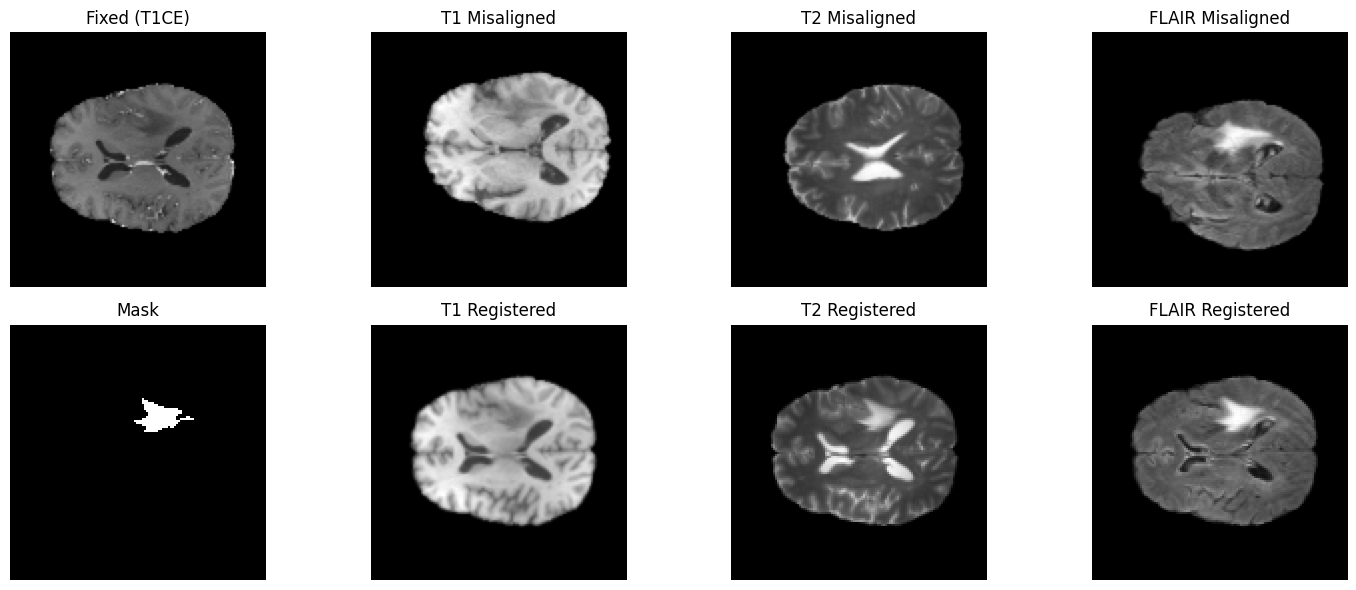

In [26]:
import matplotlib.pyplot as plt
import torch
import random

# LOAD BEST MODEL
checkpoint = torch.load("best_model.pth", map_location=DEVICE)
model.load_state_dict(checkpoint)
model.eval()

def show_slice(vol, title):
    mid = vol.shape[2] // 2
    plt.imshow(vol[:, :, mid], cmap='gray')
    plt.title(title)
    plt.axis('off')


with torch.no_grad():

    # pick RANDOM patient
    idx = random.randint(0, len(dataset)-1)
    batch = dataset[idx]

    fixed = batch["fixed"].unsqueeze(0).float().to(DEVICE)
    mask = batch["mask"].unsqueeze(0).float().to(DEVICE)

    t1 = batch["moving_t1"].unsqueeze(0).float().to(DEVICE)
    t2 = batch["moving_t2"].unsqueeze(0).float().to(DEVICE)
    flair = batch["moving_flair"].unsqueeze(0).float().to(DEVICE)

    flow_t1 = batch["flow_t1"].unsqueeze(0).float().to(DEVICE)
    flow_t2 = batch["flow_t2"].unsqueeze(0).float().to(DEVICE)
    flow_flair = batch["flow_flair"].unsqueeze(0).float().to(DEVICE)

    mask = batch["mask"].unsqueeze(0).float().to(DEVICE)

    # combine rigid flows
    rigid_flow = torch.cat([flow_t1, flow_t2, flow_flair], dim=1)

    # model input
    x = torch.cat([fixed, t1, t2, flair, rigid_flow, mask], dim=1)

    residual_flow = model(x)

    # split residual flows
    res_t1 = residual_flow[:,0:3]
    res_t2 = residual_flow[:,3:6]
    res_flair = residual_flow[:,6:9]

    # final flows
    final_flow_t1 = flow_t1 + res_t1
    final_flow_t2 = flow_t2 + res_t2
    final_flow_flair = flow_flair + res_flair

    # warp images
    reg_t1 = warp(t1, final_flow_t1)
    reg_t2 = warp(t2, final_flow_t2)
    reg_flair = warp(flair, final_flow_flair)

    # convert to numpy
    fixed = fixed[0,0].cpu().numpy()
    t1 = t1[0,0].cpu().numpy()
    t2 = t2[0,0].cpu().numpy()
    flair = flair[0,0].cpu().numpy()

    reg_t1 = reg_t1[0,0].cpu().numpy()
    reg_t2 = reg_t2[0,0].cpu().numpy()
    reg_flair = reg_flair[0,0].cpu().numpy()

    # visualization
    plt.figure(figsize=(15,6))

    # Row 1
    plt.subplot(241)
    show_slice(fixed, "Fixed (T1CE)")



    plt.subplot(242)
    show_slice(t1, "T1 Misaligned")

    plt.subplot(243)
    show_slice(t2, "T2 Misaligned")

    plt.subplot(244)
    show_slice(flair, "FLAIR Misaligned")

    # Row 2
    plt.subplot(246)
    show_slice(reg_t1, "T1 Registered")

    plt.subplot(247)
    show_slice(reg_t2, "T2 Registered")

    plt.subplot(248)
    show_slice(reg_flair, "FLAIR Registered")

    plt.subplot(245)
    show_slice(mask[0,0].cpu().numpy(), "Mask")

    plt.tight_layout()
    plt.show()